<a href="https://colab.research.google.com/github/Palak1608/Data-Science-Lab-Work/blob/main/Fun_Project/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

data = {
    "Name": ["A", "B", "C", "D", "E", "F", "G"],
    "Math": [78, 85, 96, 65, 70, 89, 92],
    "Science": [82, 88, 94, 60, 75, 91, 90],
    "English": [75, 80, 92, 58, 72, 87, 89]
}

df = pd.DataFrame(data)
df

,Name,Math,Science,English
0,A,78,82,75
1,B,85,88,80
2,C,96,94,92
3,D,65,60,58
4,E,70,75,72
5,F,89,91,87
6,G,92,90,89


In [13]:
# Check for missing values
df.isnull().sum()

# Basic statistics
df.describe()

,Math,Science,English
count,7.000000,7.000000,7.00000
mean,82.142857,82.857143,79.00000
std,11.567607,11.922368,11.83216
min,65.000000,60.000000,58.00000
25%,74.000000,78.500000,73.50000
50%,85.000000,88.000000,80.00000
75%,90.500000,90.500000,88.00000
max,96.000000,94.000000,92.00000


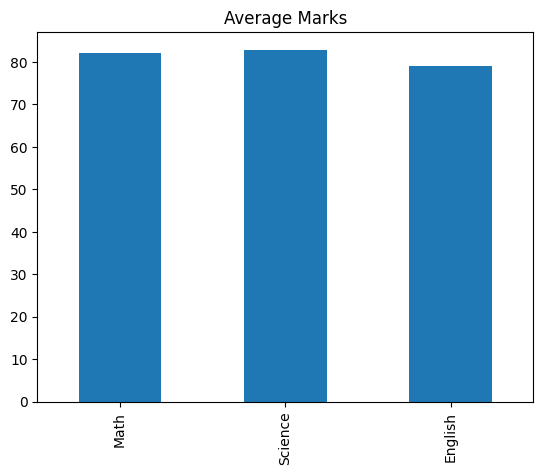

In [14]:
import matplotlib.pyplot as plt

# Average marks per subject
df.mean(numeric_only=True).plot(kind='bar', title="Average Marks")
plt.show()

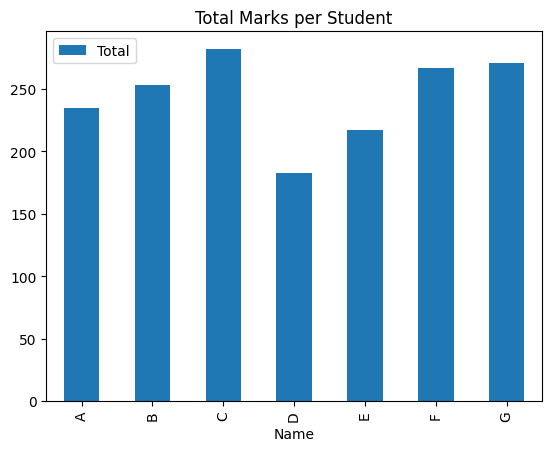

In [15]:
# Student-wise total marks
df["Total"] = df[["Math", "Science", "English"]].sum(axis=1)

df.plot(x="Name", y="Total", kind="bar", title="Total Marks per Student")
plt.show()

In [16]:
df.loc[df["Total"].idxmax()]

,2
Name,C
Math,96
Science,94
English,92
Total,282


In [17]:
from sklearn.linear_model import LinearRegression

X = df[["Math", "Science"]]
y = df["English"]

model = LinearRegression()
model.fit(X, y)

print("Model trained!")

Model trained!


In [18]:
def get_grade(total):
    if total >= 270:
        return "A"
    elif total >= 240:
        return "B"
    elif total >= 210:
        return "C"
    else:
        return "D"

df["Grade"] = df["Total"].apply(get_grade)
df

,Name,Math,Science,English,Total,Grade
0,A,78,82,75,235,C
1,B,85,88,80,253,B
2,C,96,94,92,282,A
3,D,65,60,58,183,D
4,E,70,75,72,217,C
5,F,89,91,87,267,B
6,G,92,90,89,271,A


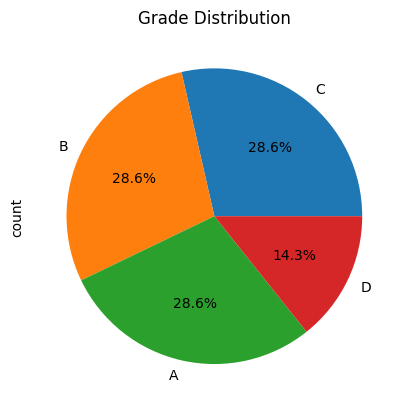

In [19]:
import matplotlib.pyplot as plt

df["Grade"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Grade Distribution")
plt.show()

In [20]:
top_student = df.loc[df["Total"].idxmax()]
print("Top Performer:")
print(top_student)

Top Performer:
Name         C
Math        96
Science     94
English     92
Total      282
Grade        A
Name: 2, dtype: object


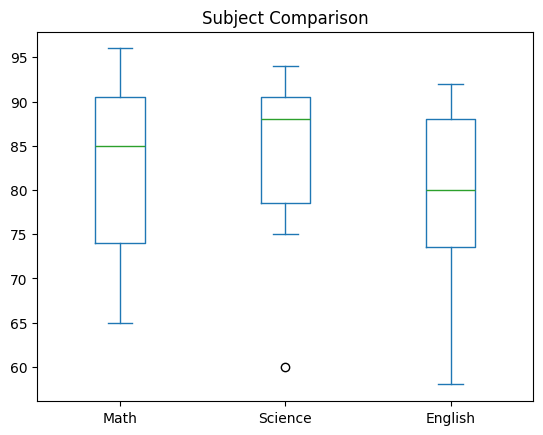

In [21]:
df[["Math", "Science", "English"]].plot(kind="box", title="Subject Comparison")
plt.show()

In [22]:
prediction = model.predict([[85, 90]])
print("Predicted English Marks:", prediction[0])

Predicted English Marks: 84.12086834163966


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
